# Visual Quality Checks

This Notebook demonstrates VisualQC integrated in [libinsitu](https://libinsitu.readthedocs.io/en/latest/)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from libinsitu import  visual_qc
from datetime import datetime
from pvlib.iotools.midc import read_midc_raw_data_from_nrel
%matplotlib inline

# Get the data

`visual_qc()` takes a Pandas dataframe as input, indexed by time, with 3 columns names : 
* **GHI**
* **DHI**
* **BNI**

It also requires at least the follwing metadata :
**latitude**, **longitude** and **altitude**. 
This meta data can be either attached to the attributes of the Dataframe (`.attrs`), or provided in the function call as parameters. 

The data can be obtained if several ways :

## Alternative 1 : Get data with pvlib

[pvlib](https://github.com/pvlib/pvlib-python) offers many function to get data from various providers.
Here we use the handler for **NREL / MIDC**

In [2]:
df = read_midc_raw_data_from_nrel(
    "UAT",
    datetime(2011, 1, 1),
    datetime(2011, 5, 30))

In [3]:
latitude = 32.22969
longitude = -110.95534
elevation = 786

In [4]:
# Show data
df

,Unnamed: 0,Year,DOY,MST,Direct Normal [W/m^2],Diffuse Horiz [W/m^2],Global Horiz (tracker) [W/m^2],Global Horiz (platform) [W/m^2],Temp CHP1 [deg C],Temp CM22 (tracker) [deg C],...,CR1000 Temp [deg C],CR1000 Battery [VDC],Air Temperature [deg C],Rel Humidity [%],Station Pressure [mBar],Avg Wind Speed @ 3m [m/s],Avg Wind Direction @ 3m [deg from N],Peak Wind Speed @ 3m [m/s],Zenith Angle [degrees],Azimuth Angle [degrees]
2011-01-01 00:00:00-07:00,0,2011,1,0,-0.429000,0.030,-1.68900,-1.98700,2.67,4.03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:01:00-07:00,0,2011,1,1,-0.358000,0.030,-1.68900,-2.03800,2.67,4.03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:02:00-07:00,0,2011,1,2,-0.157000,0.006,-1.68900,-2.03800,2.67,4.03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:03:00-07:00,0,2011,1,3,-0.014000,0.000,-1.68900,-2.03800,2.67,3.76,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:04:00-07:00,0,2011,1,4,0.000000,0.000,-1.68900,-2.03800,2.67,3.76,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-05-30 23:55:00-07:00,0,2011,150,2355,-0.636616,0.000,-2.03835,-1.40226,20.66,22.36,...,21.82,13.36,19.14,14.26,926.380,1.068,322.4,1.70,NaN,NaN
2011-05-30 23:56:00-07:00,0,2011,150,2356,-0.858356,0.000,-2.03835,-1.09252,20.66,22.32,...,21.80,13.36,19.16,14.21,926.372,1.015,327.4,1.70,NaN,NaN
2011-05-30 23:57:00-07:00,0,2011,150,2357,-0.858354,0.000,-2.03834,-1.21078,20.65,22.32,...,21.76,13.36,19.20,14.14,926.372,1.113,321.9,1.70,NaN,NaN
2011-05-30 23:58:00-07:00,0,2011,150,2358,-0.858351,0.000,-2.03833,-1.01367,20.63,22.32,...,21.75,13.36,19.30,14.13,926.380,0.396,316.6,0.95,NaN,NaN


<AxesSubplot:>

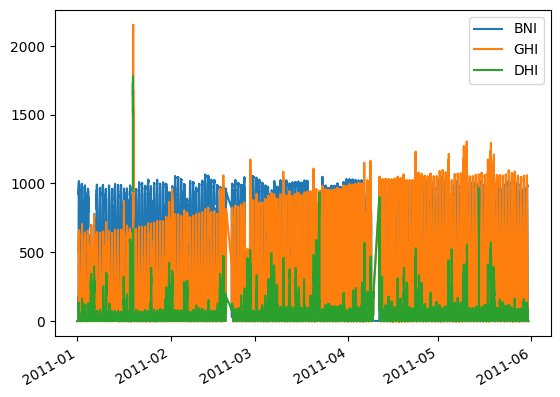

In [5]:
# Pick and rename columns for 3 components
df2 = df.rename(columns={
        "Direct Normal [W/m^2]": "BNI",
        "Diffuse Horiz [W/m^2]" : "DHI", 
        "Global Horiz (tracker) [W/m^2]" : "GHI"})
df2 = df2[["BNI", "GHI", "DHI"]]

# Filter large negative values
df2 = df2.mask(df2 < -100)

df2.plot()

## Quality check

**libinsitu** provides Qc utils for producing visual quality checks.

See the [doc of visual_qc](https://libinsitu.readthedocs.io/en/latest/api.html#visual-qc) for more details.

In [7]:
visual_qc(
    df2,
    latitude=latitude,
    longitude=longitude,
    elevation=elevation)

RuntimeError: Invalid inputs arguments, the second arguments must be an array of int or float
